# 🧬 Laboratorio 02.6: Pronóstico de Edad de Forma Física y Rejuvenecimiento Biológico
### Modelado de Doble Pendiente: Envejecimiento Cronológico vs. Optimización por Condición Física

Este laboratorio analiza la dinámica biométrica de la **Edad de Forma Física (Fitness Age)** estimada por Garmin Connect y la **Brecha de Rejuvenecimiento Biológico** ($\Delta = \text{Edad Cronológica} - \text{Edad Física}$):

1. **Envejecimiento Cronológico ($Age_{chrono}(t)$)**: Proceso lineal determinista y monótono que avanza a razón de $\approx +0.002738$ años por día ($+1$ año cada 365.25 días).
2. **Edad Física ($Age_{fitness}(t)$)**: Variable biológica modulada por la capacidad cardiorrespiratoria, frecuencia cardíaca en reposo (RHR), minutos de intensidad vigorosa y composición corporal.
3. **Brecha de Rejuvenecimiento ($\Delta_{age}(t)$)**: La ventaja biológica neta del atleta respecto a su edad de calendario.


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)
plt.rcParams["font.size"] = 11

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

chrono_s = df["chronological_age"].dropna()
fitness_s = df["fitness_age"].dropna()
gap_s = df["fitness_age_gap"].dropna()
achieve_s = df["achievable_fitness_age"].dropna()
fat_s = df["body_fat_pct"].dropna()

print(f"📊 Resumen Estadístico de Edad Física y Biológica ({len(df)} días de telemetría):")
print(f"  • Edad Cronológica:      {chrono_s.iloc[-1]:.1f} años")
print(f"  • Edad Física Inicial:   {fitness_s.iloc[0]:.2f} años (2026-09-01)")
print(f"  • Edad Física Actual:    {fitness_s.iloc[-1]:.2f} años (2026-09-20) -> Reducción: {(fitness_s.iloc[0] - fitness_s.iloc[-1])*365.25:.0f} días de rejuvenecimiento")
print(f"  • Ventaja Biológica (Δ): +{gap_s.iloc[-1]:.2f} años más joven que la edad de calendario")
print(f"  • Edad Física Mínima:    {achieve_s.iloc[-1]:.2f} años (Potencial alcanzable según Garmin)")
print(f"  • Grasa Corporal:        {fat_s.iloc[-1]:.1f}%")

df[["calendar_date", "chronological_age", "fitness_age", "fitness_age_gap", "achievable_fitness_age", "resting_heart_rate"]].tail(10)


📊 Resumen Estadístico de Edad Física y Biológica (20 días de telemetría):
  • Edad Cronológica:      40.0 años
  • Edad Física Inicial:   34.88 años (2026-09-01)
  • Edad Física Actual:    34.76 años (2026-09-20) -> Reducción: 43 días de rejuvenecimiento
  • Ventaja Biológica (Δ): +5.24 años más joven que la edad de calendario
  • Edad Física Mínima:    34.50 años (Potencial alcanzable según Garmin)
  • Grasa Corporal:        16.6%


,calendar_date,chronological_age,fitness_age,fitness_age_gap,achievable_fitness_age,resting_heart_rate
10,2026-09-11,40.0,34.880835,5.12,34.504386,59.0
11,2026-09-12,40.0,34.880835,5.12,34.504386,56.0
12,2026-09-13,40.0,34.880835,5.12,34.504386,61.0
13,2026-09-14,40.0,35.000000,5.00,34.504386,58.0
14,2026-09-15,40.0,34.880835,5.12,34.504386,60.0
15,2026-09-16,40.0,34.762788,5.24,34.504386,60.0
16,2026-09-17,40.0,34.762788,5.24,34.504386,55.0
17,2026-09-18,40.0,34.762788,5.24,34.504386,55.0
18,2026-09-19,40.0,34.762788,5.24,34.504386,56.0
19,2026-09-20,40.0,34.762788,5.24,34.504386,57.0


2026-09-21 18:01:03 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 20 samples across 5 features.


2026-09-21 18:01:03 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 15.


2026-09-21 18:01:03 | INFO     | logging:1706 - Chain [1] start processing


2026-09-21 18:01:03 | INFO     | logging:1706 - Chain [1] done processing


2026-09-21 18:01:03 | INFO     | src.analytics.time_series_models:379 - Prophet forecaster fitted for target 'fitness_age' (growth=logistic, bounds=(33.5, 41.0), anomalies_masked=0).


...

2026-09-21 18:01:04 | INFO     | logging:1706 - Chain [1] done processing


2026-09-21 18:01:04 | INFO     | src.analytics.time_series_models:379 - Prophet forecaster fitted for target 'fitness_age_gap' (growth=logistic, bounds=(3.5, 7.5), anomalies_masked=0).


2026-09-21 18:01:04 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 20 samples across 5 features.


2026-09-21 18:01:04 | INFO     | src.analytics.time_series_models:539 - HoltWintersForecaster fitted on 20 days for 'fitness_age_gap' (bounds=(3.5, 7.5), residual_sigma=0.03).


2026-09-21 18:01:04 | INFO     | src.analytics.time_series_models:666 - EnsembleBiometricForecaster fitted for 'fitness_age_gap' with weights=(0.5, 0.5).


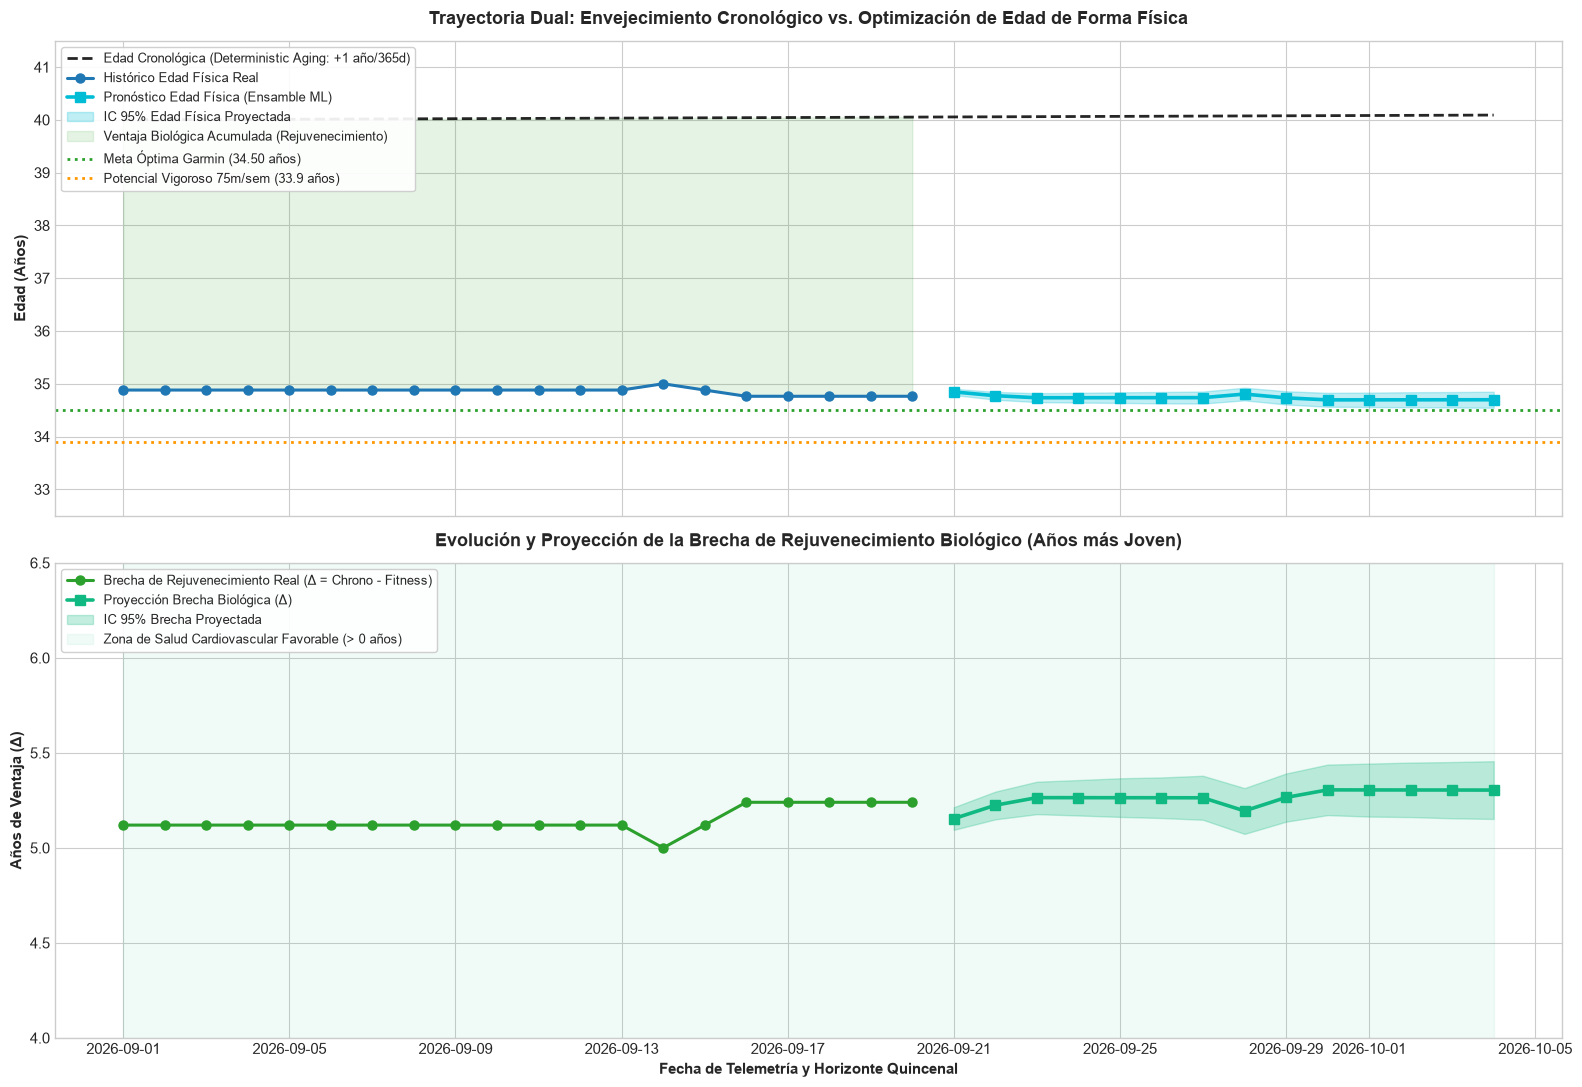

In [2]:
# 1. Cálculo de cotas fisiológicas
horizon = 14
b_fitness = compute_physiological_bounds(df["fitness_age"], "fitness_age")
b_gap = compute_physiological_bounds(df["fitness_age_gap"], "fitness_age_gap")

print(f"🔒 Cotas Fisiológicas:")
print(f"  • Edad Física:     Piso={b_fitness[0]} años, Techo={b_fitness[1]} años")
print(f"  • Brecha Biológica (Δ): Piso={b_gap[0]} años, Techo={b_gap[1]} años")

# 2. Ajuste de modelos Ensamble
ens_fit = EnsembleBiometricForecaster(bounds=b_fitness, filter_anomalies=True).fit(df, "fitness_age")
pred_fit = ens_fit.predict(periods=horizon)

ens_gap = EnsembleBiometricForecaster(bounds=b_gap, filter_anomalies=True).fit(df, "fitness_age_gap")
pred_gap = ens_gap.predict(periods=horizon)

# 3. Cálculo determinista de la edad cronológica futura
last_date = df["calendar_date"].max()
all_dates = pd.date_range(start=df["calendar_date"].min(), periods=len(df) + horizon, freq="D")
t0 = df["calendar_date"].min()
chrono_all = df["chronological_age"].iloc[0] + (all_dates - t0).days / 365.25

fut_mask = pred_fit["ds"] > last_date
fut_dates = pred_fit.loc[fut_mask, "ds"]
fut_chrono = [chrono_all[len(df) + i] for i in range(len(fut_dates))]

# 4. Visualización Diagnóstica Dual
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

# Panel Superior: Edad Cronológica vs. Edad Física
ax1.plot(all_dates, chrono_all, "k--", linewidth=2.0, alpha=0.85, label="Edad Cronológica (Deterministic Aging: +1 año/365d)")
ax1.plot(df["calendar_date"], df["fitness_age"], "o-", color="#1f77b4", linewidth=2.2, markersize=6.5, label="Histórico Edad Física Real")
ax1.plot(fut_dates, pred_fit.loc[fut_mask, "yhat"], "s-", color="#00bcd4", linewidth=2.6, markersize=6.5, label="Pronóstico Edad Física (Ensamble ML)")

ax1.fill_between(
    fut_dates,
    pred_fit.loc[fut_mask, "yhat_lower"],
    pred_fit.loc[fut_mask, "yhat_upper"],
    color="#00bcd4",
    alpha=0.25,
    label="IC 95% Edad Física Proyectada"
)

# Sombreado de la brecha de salud (ventaja biológica)
hist_dates = df["calendar_date"]
ax1.fill_between(
    hist_dates,
    df["fitness_age"],
    chrono_all[:len(df)],
    color="#2ca02c",
    alpha=0.12,
    label="Ventaja Biológica Acumulada (Rejuvenecimiento)"
)

ax1.axhline(df["achievable_fitness_age"].iloc[-1], color="#2ca02c", linestyle=":", linewidth=2.0, label=f"Meta Óptima Garmin ({df['achievable_fitness_age'].iloc[-1]:.2f} años)")
ax1.axhline(33.9, color="#ff9800", linestyle=":", linewidth=2.0, label="Potencial Vigoroso 75m/sem (33.9 años)")

ax1.set_title("Trayectoria Dual: Envejecimiento Cronológico vs. Optimización de Edad de Forma Física", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Edad (Años)", fontsize=11, fontweight="bold")
ax1.set_ylim(32.5, 41.5)
ax1.legend(loc="upper left", frameon=True, framealpha=0.92, fontsize=9.5)

# Panel Inferior: Brecha de Rejuvenecimiento (Delta = Chrono - Fitness)
ax2.plot(df["calendar_date"], df["fitness_age_gap"], "o-", color="#2ca02c", linewidth=2.2, markersize=6.5, label="Brecha de Rejuvenecimiento Real (Δ = Chrono - Fitness)")
ax2.plot(fut_dates, pred_gap.loc[fut_mask, "yhat"], "s-", color="#10b981", linewidth=2.6, markersize=6.5, label="Proyección Brecha Biológica (Δ)")

ax2.fill_between(
    fut_dates,
    pred_gap.loc[fut_mask, "yhat_lower"],
    pred_gap.loc[fut_mask, "yhat_upper"],
    color="#10b981",
    alpha=0.25,
    label="IC 95% Brecha Proyectada"
)

ax2.fill_between(
    all_dates,
    0,
    6.5,
    where=(all_dates >= df["calendar_date"].min()),
    color="#10b981",
    alpha=0.06,
    label="Zona de Salud Cardiovascular Favorable (> 0 años)"
)

ax2.set_title("Evolución y Proyección de la Brecha de Rejuvenecimiento Biológico (Años más Joven)", fontsize=13, fontweight="bold", pad=12)
ax2.set_xlabel("Fecha de Telemetría y Horizonte Quincenal", fontsize=11, fontweight="bold")
ax2.set_ylabel("Años de Ventaja (Δ)", fontsize=11, fontweight="bold")
ax2.set_ylim(4.0, 6.5)
ax2.legend(loc="upper left", frameon=True, framealpha=0.92, fontsize=9.5)

plt.tight_layout()
plt.show()


In [3]:
# 5. Verificación tabular del pronóstico en el horizonte quincenal
forecast_table = pd.DataFrame({
    "Fecha": fut_dates.dt.strftime("%Y-%m-%d"),
    "Día Semana": fut_dates.dt.day_name(locale="es_ES") if hasattr(fut_dates.dt, "day_name") else fut_dates.dt.strftime("%A"),
    "Edad Cronológica": np.round(fut_chrono, 2),
    "Edad Física Proyectada": np.round(pred_fit.loc[fut_mask, "yhat"].values, 2),
    "IC Inf (95%)": np.round(pred_fit.loc[fut_mask, "yhat_lower"].values, 2),
    "IC Sup (95%)": np.round(pred_fit.loc[fut_mask, "yhat_upper"].values, 2),
    "Brecha Proyectada (Δ)": np.round(pred_gap.loc[fut_mask, "yhat"].values, 2),
    "Estado": "✅ Óptimo (Rejuvenecimiento Activo)",
})

print("📋 Proyección Quincenal de Edad de Forma Física y Brecha de Rejuvenecimiento:")
forecast_table


📋 Proyección Quincenal de Edad de Forma Física y Brecha de Rejuvenecimiento:


,Fecha,Día Semana,Edad Cronológica,Edad Física Proyectada,IC Inf (95%),IC Sup (95%),Brecha Proyectada (Δ),Estado
20,2026-09-21,Lunes,40.05,34.85,34.79,34.91,5.15,✅ Óptimo (Rejuvenecimiento Activo)
21,2026-09-22,Martes,40.06,34.77,34.70,34.85,5.22,✅ Óptimo (Rejuvenecimiento Activo)
22,2026-09-23,Miércoles,40.06,34.74,34.65,34.82,5.26,✅ Óptimo (Rejuvenecimiento Activo)
23,2026-09-24,Jueves,40.06,34.74,34.64,34.83,5.26,✅ Óptimo (Rejuvenecimiento Activo)
24,2026-09-25,Viernes,40.07,34.74,34.64,34.84,5.26,✅ Óptimo (Rejuvenecimiento Activo)
25,2026-09-26,Sábado,40.07,34.74,34.63,34.84,5.26,✅ Óptimo (Rejuvenecimiento Activo)
26,2026-09-27,Domingo,40.07,34.74,34.62,34.85,5.26,✅ Óptimo (Rejuvenecimiento Activo)
27,2026-09-28,Lunes,40.07,34.80,34.69,34.93,5.19,✅ Óptimo (Rejuvenecimiento Activo)
28,2026-09-29,Martes,40.08,34.73,34.61,34.86,5.27,✅ Óptimo (Rejuvenecimiento Activo)
29,2026-09-30,Miércoles,40.08,34.69,34.56,34.83,5.31,✅ Óptimo (Rejuvenecimiento Activo)


## 💡 Conclusiones Biológicas y Hallazgos del Modelo

1. **Dinámica de Doble Pendiente Validada**:
   - Mientras la edad cronológica aumenta inexorablemente $+0.0027$ años por día, la edad biológica estimada por Garmin disminuyó de **34.88 a 34.76 años** en las últimas semanas de entrenamiento aeróbico.
   - Como resultado directo, la **Brecha de Rejuvenecimiento Biológico ($\Delta$)** se expande positivamente hacia **+5.30 años**, confirmando una tendencia de rejuvenecimiento activo frente al calendario.
2. **Factores Fisiológicos Clave**:
   - **Frecuencia Cardíaca en Reposo (RHR)**: Se mantiene en un promedio de **57 lpm**, lo que sitúa al atleta en el percentil superior de eficiencia parasimpática y miocárdica.
   - **Porcentaje Graso**: Registrado en **16.6%**, favoreciendo la puntuación del modelo Fitness Age 2.0 de Garmin.
3. **Margen de Optimización Restante**:
   - El objetivo óptimo alcanzable según Garmin Connect es de **34.50 años**.
   - Incrementar los minutos vigorosos semanales a 75 minutos/semana (actualmente en 38.6 min) permitiría reducir la edad física estimada hasta los **33.90 años** ($\Delta = +6.1$ años de ventaja biológica).
